In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

In [6]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [7]:
df["Family"] = df["SibSp"] + df["Parch"]
df["Child"] = (df["Age"] < 18).astype(int)
df["Alone"] = (df["Family"] == 0).astype(int)
df["Expensive"] = (df["Fare"] > df["Fare"].median()*2).astype(int)

In [8]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [9]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [10]:
df.groupby(["Sex", "Pclass"])["Survived"].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

In [11]:
df.groupby(["Sex", "Alone", "Age"])["Survived"].mean()

Sex     Alone  Age  
female  0      0.75     1.000000
               1.00     1.000000
               2.00     0.333333
               3.00     0.500000
               4.00     1.000000
                          ...   
male    1      70.00    0.000000
               70.50    0.000000
               71.00    0.000000
               74.00    0.000000
               80.00    1.000000
Name: Survived, Length: 223, dtype: float64

хрень какая-то

In [12]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 17, 29, 49, float("inf")],
    labels=["0-17", "18-29", "30-49", "50+"]
)

df.groupby(["Sex", "Alone", "AgeGroup"])["Survived"].agg(
    mean="mean",
    std="std",
    count="count"
)

/tmp/ipykernel_16/2405433076.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Sex", "Alone", "AgeGroup"])["Survived"].agg(


mean       std  count
Sex    Alone AgeGroup                           
female 0     0-17      0.659091  0.479495     44
             18-29     0.679487  0.469694     78
             30-49     0.735849  0.445099     53
             50+       1.000000  0.000000     13
       1     0-17      0.818182  0.404520     11
             18-29     0.746269  0.438430     67
             30-49     0.846154  0.365518     39
             50+       0.777778  0.440959      9
male   0     0-17      0.478261  0.505047     46
             18-29     0.172414  0.381039     58
             30-49     0.224490  0.421570     49
             50+       0.153846  0.375534     13
       1     0-17      0.083333  0.288675     12
             18-29     0.138776  0.346420    245
             30-49     0.208696  0.408155    115
             50+       0.128205  0.338688     39

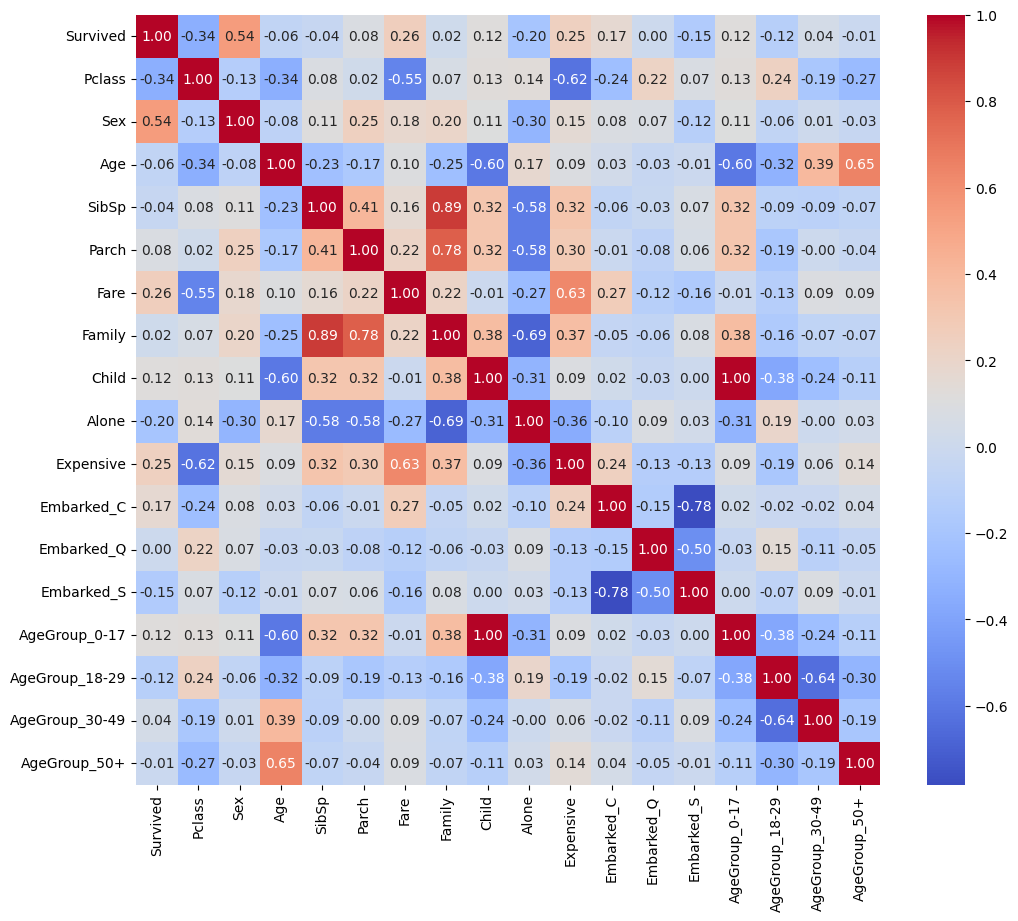

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

df = pd.get_dummies(
    df,
    columns=["Embarked", "AgeGroup"],
    dtype=int
)

corr = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [14]:
corr["Survived"].drop("Survived").sort_values(key=abs, ascending=False).head(10)

Sex               0.543351
Pclass           -0.338481
Fare              0.257307
Expensive         0.246766
Alone            -0.203367
Embarked_C        0.168240
Embarked_S       -0.149683
AgeGroup_0-17     0.122239
Child             0.122239
AgeGroup_18-29   -0.115206
Name: Survived, dtype: float64

Выводы:
- синтетическая метрика Expensive взята с потолка, а потому бесполезна и проигрывает Fare, из которой она была получена
- синтетическая метрика Alone показала неплохой результат
- решение разбить возраст на группы позволило найти корреляции, невидимые с дефолтным Age. в частности, детей спасали чуть чаще, а молодых людей - реже (ну или, возможно, молодые люди сами кидались на рожон. а еще они чаще были обслуживающим персоналом: корреляция с Pclass и Alone даже больше у этой группы, чем с Survival)
- самое заметное: женщины выживали чаще мужчин
- пассажиры более высокого класса тоже значительно чаще выживали. Это видно из Pclass и Fare
- путешествовавшие в одиночку выживали реже. вероятно, потому, что это чаще мужчины и у них чаще ниже класс